# 🎓 Student Placement Prediction System — Part 1: Machine Learning

**Goal:** given a student's academic and skill profile, estimate
1. **the chance (%) of being placed**, and
2. **the likely salary package in LPA / ₹ per year** (with a realistic range).

**Design (two-stage system)**

| Stage | Task | Trained on | Output |
|---|---|---|---|
| 1 | Binary classification | all students | P(placed) |
| 2 | Regression | **placed students only** (salary is 0 for unplaced) | salary if placed (+ 10th–90th percentile range) |
| Combined | | | Expected LPA = P(placed) × salary-if-placed |

**Four models are compared for each stage (basic → advanced):**
1. Logistic Regression / Ridge (linear baseline)
2. Random Forest (bagging)
3. XGBoost (gradient boosting)
4. Stacking ensemble (LR + RF + XGBoost + LightGBM → meta-learner)

**Innovations added**
- Leakage-safe split-first workflow + scikit-learn `Pipeline` (nothing is ever fitted on test data)
- Statistically-driven feature selection (on the training set only) + fairness exclusion of `gender` / `age`
- Engineered features (`skill_index`, `experience_index`, `has_backlog`) validated by ablation, not assumed
- *One-standard-error rule* for model selection (prefer the simpler model when it is statistically tied)
- **Calibrated probabilities** so "62 %" really means ≈ 62 %
- **Quantile regression** for a salary *range*, not just a single number
- Permutation importance + SHAP explanations
- Ready-to-use `PlacementPredictor` class for the backend/frontend (Part 2)

**Output folder (auto-created, zip-ready for VS Code)**
```
placement_project/
├── ML/
│   ├── 01_data/            raw CSV copy
│   ├── 02_notebook/        this notebook
│   ├── 03_models/          *.joblib pipelines, feature_schema.json, model_card.json
│   ├── 04_reports/         metrics CSV/JSON + figures/
│   └── 05_app_ready/       ml_utils.py (predictor), requirements.txt, README, example input
└── frontend/               React app goes here (Part 2)
```


## 0. Setup

In [1]:
# [SETUP] Imports, global configuration, reproducibility seed.
import os, sys, json, time, glob, shutil, warnings, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

from sklearn.base import clone
from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold,
                                     cross_validate, RandomizedSearchCV, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              StackingClassifier, StackingRegressor)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_selection import f_classif, f_regression, mutual_info_classif, mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, brier_score_loss, log_loss, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
try:
    import shap
except Exception:
    shap = None

warnings.filterwarnings("ignore")   # keep the notebook output readable (library deprecation chatter only)
sns.set_theme(style="whitegrid", context="notebook")

# ---------------- CONFIG ----------------
RANDOM_STATE = 42
QUICK_MODE   = os.environ.get("QUICK_MODE", "0") == "1"   # True = tiny/fast smoke-test run (set env var QUICK_MODE=1)
TEST_SIZE    = 0.20      # hold-out test set (locked away until the final evaluation)
CV_FOLDS     = 3 if QUICK_MODE else 5
TUNE_SAMPLE  = 8000 if QUICK_MODE else 30000    # rows used for hyper-parameter search (speed)
N_ITER       = 3 if QUICK_MODE else 10          # random-search iterations per model
ALPHA        = 0.001     # significance level for feature selection (stricter than Bonferroni for ~20 tests)
np.random.seed(RANDOM_STATE)

print("QUICK_MODE:", QUICK_MODE, "| CV folds:", CV_FOLDS)

QUICK_MODE: False | CV folds: 5


In [2]:
# [SETUP] Create the sequential project folder: placement_project/ML/01..05 + placement_project/frontend (Kaggle or local VS Code).
ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT_DIR = Path("/kaggle/working") / "placement_project"
else:
    cwd = Path.cwd()
    PROJECT_DIR = cwd.parent.parent if (cwd.name == "02_notebook" and cwd.parent.name == "ML") else cwd / "placement_project"
ML_DIR   = PROJECT_DIR / "ML"
BASE_DIR = PROJECT_DIR
DIRS = {
    "data":     ML_DIR / "01_data",
    "notebook": ML_DIR / "02_notebook",
    "models":   ML_DIR / "03_models",
    "reports":  ML_DIR / "04_reports",
    "figures":  ML_DIR / "04_reports" / "figures",
    "app":      ML_DIR / "05_app_ready",
    "frontend": PROJECT_DIR / "frontend",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)
(DIRS["frontend"] / "README.md").write_text("React frontend (Part 2) goes here. It will call ML/05_app_ready/ml_utils.PlacementPredictor through a small API.\n")

def savefig(name):
    # Save the current matplotlib figure into 04_reports/figures and display it.
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Project root:", PROJECT_DIR)


Project root: /kaggle/working/placement_project


In [3]:
# [SETUP] Write the reusable module `ml_utils.py` into 05_app_ready/.
# WHY a separate file? The saved model pipelines contain the custom `FeatureEngineer` class. Python can only
# reload (joblib.load) them later if that class lives in an importable module -> the backend imports the same file.
ML_UTILS_SRC = r'''
import json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from sklearn.base import BaseEstimator, TransformerMixin

SKILL_COLS = ["coding_skill_score", "aptitude_score", "communication_skill_score", "logical_reasoning_score"]


class FeatureEngineer(BaseEstimator, TransformerMixin):
    # Stateless feature engineering (nothing is learned from data -> cannot leak information).
    #   skill_index      = mean of the four skill scores
    #   experience_index = internships + projects
    #   has_backlog      = 1 if backlogs > 0 else 0
    def __init__(self, add_features=True):
        self.add_features = add_features

    def _new_cols(self, cols):
        cols = list(cols)
        new = []
        if self.add_features:
            if sum(c in cols for c in SKILL_COLS) >= 2:
                new.append("skill_index")
            if "internships_count" in cols and "projects_count" in cols:
                new.append("experience_index")
            if "backlogs" in cols:
                new.append("has_backlog")
        return new

    def fit(self, X, y=None):
        self.columns_in_ = list(X.columns)
        return self

    def transform(self, X):
        X = X.copy()
        for c in self._new_cols(X.columns):
            if c == "skill_index":
                X[c] = X[[s for s in SKILL_COLS if s in X.columns]].mean(axis=1)
            elif c == "experience_index":
                X[c] = X["internships_count"] + X["projects_count"]
            elif c == "has_backlog":
                X[c] = (X["backlogs"] > 0).astype(int)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(list(self.columns_in_) + self._new_cols(self.columns_in_), dtype=object)


def format_inr(amount):
    # Indian digit grouping, e.g. 1350000 -> "Rs 13,50,000"
    s = str(int(round(amount)))
    if len(s) <= 3:
        return "Rs " + s
    head, tail = s[:-3], s[-3:]
    parts = []
    while len(head) > 2:
        parts.insert(0, head[-2:])
        head = head[:-2]
    if head:
        parts.insert(0, head)
    return "Rs " + ",".join(parts + [tail])


class PlacementPredictor:
    # Loads the saved models and returns placement chance + salary estimate for one student (dict) or many (DataFrame).
    def __init__(self, model_dir=None):
        d = Path(model_dir) if model_dir else Path(__file__).resolve().parent.parent / "03_models"
        self.clf = joblib.load(d / "placement_classifier.joblib")
        self.reg = joblib.load(d / "salary_regressor.joblib")
        self.q_lo = joblib.load(d / "salary_q10.joblib")
        self.q_hi = joblib.load(d / "salary_q90.joblib")
        with open(d / "feature_schema.json") as f:
            self.schema = json.load(f)
        self.pq = np.array(self.schema.get("probability_quantiles", []), dtype=float)

    def _frame(self, data):
        df = pd.DataFrame([data]) if isinstance(data, dict) else data.copy()
        missing = [c for c in self.schema["input_features"] if c not in df.columns]
        if missing:
            raise ValueError(f"Missing input fields: {missing}")
        for col, meta in self.schema["features"].items():
            if meta["type"] in ("integer", "float"):
                df[col] = df[col].astype(float).clip(meta["min"], meta["max"])
        return df

    def predict_frame(self, data):
        df = self._frame(data)
        p = self.clf.predict_proba(df[self.schema["classifier_features"]])[:, 1]
        rf = self.schema["regressor_features"]
        sal = np.clip(self.reg.predict(df[rf]), 0, None)
        lo = np.clip(self.q_lo.predict(df[rf]), 0, None)
        hi = np.clip(self.q_hi.predict(df[rf]), 0, None)
        lo, hi = np.minimum(lo, sal), np.maximum(hi, sal)      # guarantee lo <= point <= hi
        pct = np.interp(p, self.pq, np.linspace(0, 100, len(self.pq))) if len(self.pq) > 1 else np.full(len(p), np.nan)
        return pd.DataFrame({"placement_probability": p, "profile_percentile": pct, "salary_if_placed_lpa": sal,
                             "salary_low_lpa": lo, "salary_high_lpa": hi,
                             "expected_lpa": p * sal})

    def predict(self, data):
        r = self.predict_frame(data).iloc[0]
        p, sal, lo, hi, exp = (float(r[k]) for k in ["placement_probability", "salary_if_placed_lpa",
                                                      "salary_low_lpa", "salary_high_lpa", "expected_lpa"])
        return {
            "profile_percentile": None if np.isnan(r["profile_percentile"]) else round(float(r["profile_percentile"]), 1),
            "placement_probability": round(p, 4),
            "placement_percent": round(100 * p, 1),
            "predicted_placed": bool(p >= 0.5),
            "salary_if_placed_lpa": round(sal, 2),
            "salary_range_lpa": [round(lo, 2), round(hi, 2)],
            "salary_if_placed_inr": int(round(sal * 1e5)),
            "salary_range_inr": [int(round(lo * 1e5)), int(round(hi * 1e5))],
            "salary_if_placed_text": format_inr(sal * 1e5) + " per year",
            "expected_lpa": round(exp, 2),
            "expected_inr": int(round(exp * 1e5)),
        }
'''
(DIRS["app"] / "ml_utils.py").write_text(ML_UTILS_SRC.lstrip("\n"))

sys.path.insert(0, str(DIRS["app"]))
import ml_utils
importlib.reload(ml_utils)
from ml_utils import FeatureEngineer, PlacementPredictor
print("ml_utils.py written to", DIRS["app"] / "ml_utils.py")

ml_utils.py written to /kaggle/working/placement_project/ML/05_app_ready/ml_utils.py


## 1. Load & audit the data

In [4]:
# [LOAD] Locate the CSV automatically (Kaggle input folder, local 01_data/, or current folder) and copy it to 01_data/.
CSV_NAME = "student_placement_prediction_dataset_2026.csv"
cands  = glob.glob(f"/kaggle/input/**/{CSV_NAME}", recursive=True)
cands += [p for p in glob.glob("/kaggle/input/**/*.csv", recursive=True) if "placement" in p.lower()]
cands += [str(DIRS["data"] / CSV_NAME), str(Path.cwd() / CSV_NAME), str(Path.cwd().parent / "01_data" / CSV_NAME)]
csv_path = next((Path(p) for p in cands if Path(p).exists()), None)
assert csv_path is not None, "CSV not found - add the Kaggle dataset to the notebook or put the CSV next to it."

df = pd.read_csv(csv_path)
if csv_path.resolve() != (DIRS["data"] / CSV_NAME).resolve():
    shutil.copy(csv_path, DIRS["data"] / CSV_NAME)

if QUICK_MODE:                                   # fast smoke-test only
    df = df.sample(20000, random_state=RANDOM_STATE).reset_index(drop=True)

print("Loaded:", csv_path, "->", df.shape)
df.head()

Loaded: /kaggle/input/datasets/kishlaytejeswi/student-placement-prediction-dataset/student_placement_prediction_dataset_2026.csv -> (100000, 26)


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [5]:
# [AUDIT] Data quality checks (no data is changed here): types, missing values, duplicates, ranges.
print("Shape:", df.shape)
print("Missing values per column:\n", df.isna().sum()[df.isna().sum() > 0] if df.isna().any().any() else "None")
print("Duplicate rows:", df.duplicated().sum(), "| student_id unique:", df["student_id"].is_unique)
display(df.dtypes.to_frame("dtype").T)
display(df.describe().T.round(2))

Shape: (100000, 26)
Missing values per column:
 None
Duplicate rows: 0 | student_id unique: True


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
dtype,int64,int64,object,float64,object,object,int64,int64,int64,float64,...,float64,float64,int64,float64,float64,object,float64,float64,object,float64


,count,mean,std,min,25%,50%,75%,max
student_id,100000.0,50000.50,28867.66,1.0,25000.75,50000.50,75000.25,100000.00
age,100000.0,21.01,2.00,18.0,19.00,21.00,23.00,24.00
cgpa,100000.0,7.50,0.99,4.5,6.82,7.50,8.18,10.00
internships_count,100000.0,1.50,1.23,0.0,1.00,1.00,2.00,8.00
projects_count,100000.0,3.00,1.73,0.0,2.00,3.00,4.00,13.00
certifications_count,100000.0,2.01,1.42,0.0,1.00,2.00,3.00,11.00
coding_skill_score,100000.0,69.83,14.69,20.0,59.81,70.01,80.06,100.00
aptitude_score,100000.0,64.99,14.84,20.0,54.89,65.01,75.08,100.00
communication_skill_score,100000.0,67.96,13.85,20.0,58.59,67.97,77.50,100.00
logical_reasoning_score,100000.0,65.93,14.83,20.0,55.94,66.00,76.11,100.00


In [6]:
# [TARGETS + LEAKAGE CHECK]
# Two targets are derived:
#   placed (0/1)        -> classification target
#   salary_package_lpa  -> regression target (only meaningful for placed students)
# LEAKAGE RULE: `placement_status` and `salary_package_lpa` are *outcomes*. They must NEVER be used as input features.
df["placed"] = (df["placement_status"] == "Placed").astype(int)

consistent = ((df["salary_package_lpa"] > 0) == (df["placed"] == 1)).all()
print("salary > 0  <=>  Placed :", consistent)
print("Placement rate:", round(df["placed"].mean(), 4), "(near-balanced -> no SMOTE / resampling needed)")
print("Salary of placed students (LPA):\n", df.loc[df.placed == 1, "salary_package_lpa"].describe().round(2))

salary > 0  <=>  Placed : True
Placement rate: 0.5446 (near-balanced -> no SMOTE / resampling needed)
Salary of placed students (LPA):
 count    54459.00
mean        13.32
std          1.59
min          7.11
25%         12.23
50%         13.30
75%         14.39
max         20.44
Name: salary_package_lpa, dtype: float64


## 2. Train / test split — *before* any statistics or fitting
The test set is locked away now. Every later step that "learns" something (feature selection, scaling, tuning,
calibration) uses **only the training portion**. Cross-validation folds are created *inside* the training portion.

In [7]:
# [SPLIT] Stratified 80/20 split so both parts keep the same placement rate.
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df["placed"], random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Regression works on placed students only
train_placed = train_df[train_df["placed"] == 1].reset_index(drop=True)
test_placed  = test_df[test_df["placed"] == 1].reset_index(drop=True)

print(f"train: {len(train_df):,} | test: {len(test_df):,} | train placed: {len(train_placed):,} | test placed: {len(test_placed):,}")
print("placement rate  train/test:", round(train_df.placed.mean(), 4), "/", round(test_df.placed.mean(), 4))

train: 80,000 | test: 20,000 | train placed: 43,567 | test placed: 10,892
placement rate  train/test: 0.5446 / 0.5446


## 3. Exploratory data analysis (training data only)

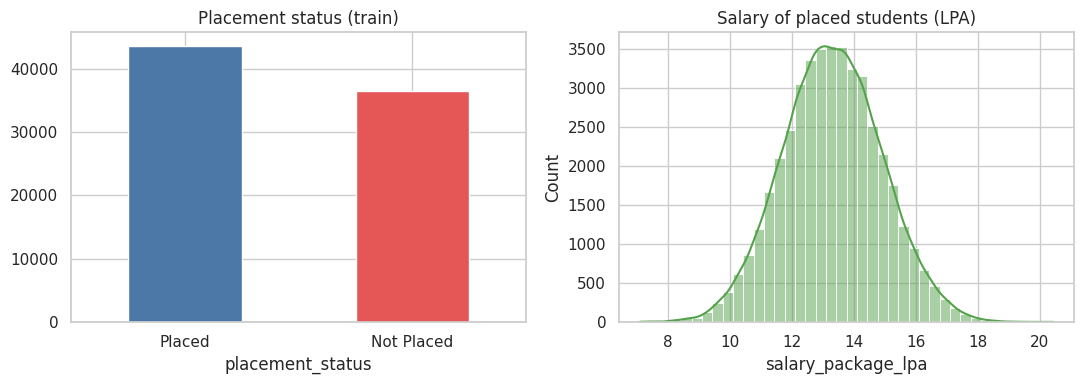

In [8]:
# [EDA] Target distributions.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
train_df["placement_status"].value_counts().plot.bar(ax=ax[0], color=["#4C78A8", "#E45756"], rot=0)
ax[0].set_title("Placement status (train)")
sns.histplot(train_placed["salary_package_lpa"], bins=40, kde=True, ax=ax[1], color="#54A24B")
ax[1].set_title("Salary of placed students (LPA)")
savefig("01_target_distributions")

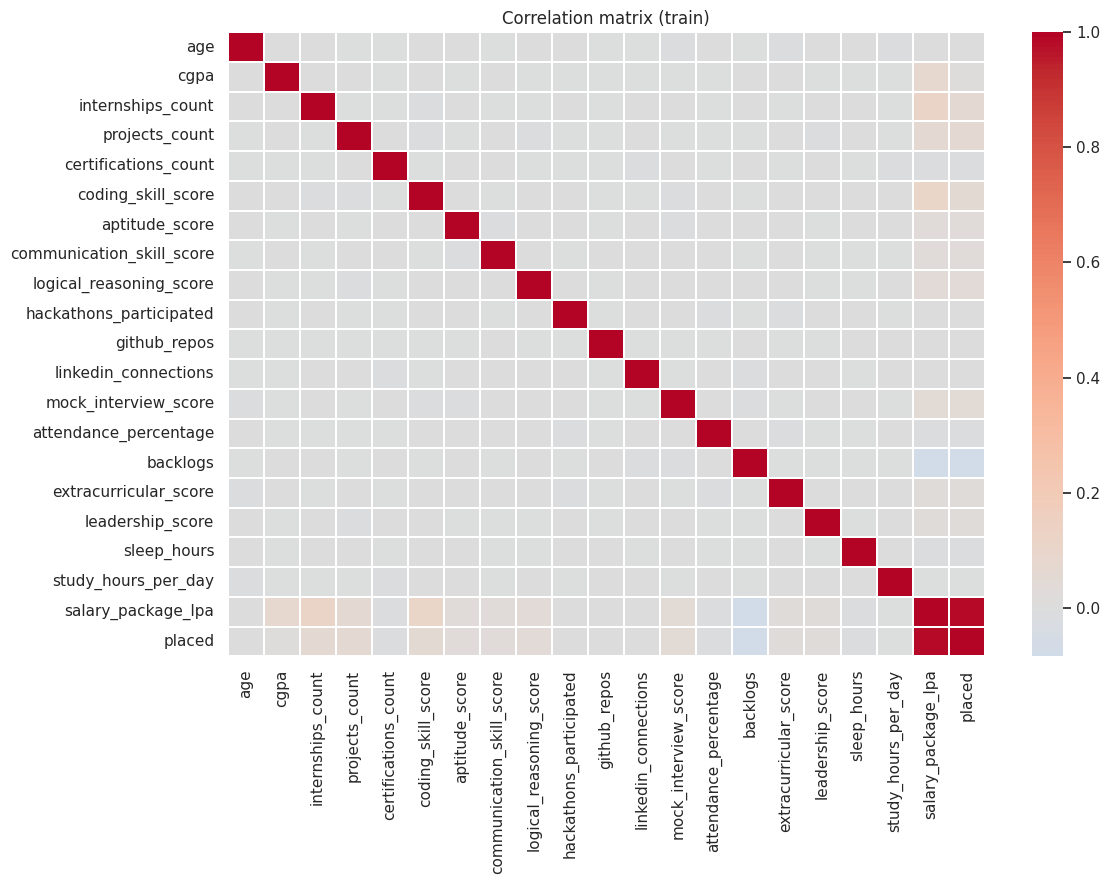

,corr_with_placed,corr_with_salary(placed only)
backlogs,-0.085,0.008
internships_count,0.062,0.390
projects_count,0.060,-0.009
coding_skill_score,0.051,0.455
mock_interview_score,0.046,-0.005
logical_reasoning_score,0.036,-0.001
aptitude_score,0.032,-0.000
communication_skill_score,0.030,0.000
leadership_score,0.023,0.004
extracurricular_score,0.020,0.009


In [9]:
# [EDA] Correlation heat-map of numeric columns (identifier and outcome flags excluded).
num_cols_all = train_df.select_dtypes("number").columns.drop(["student_id"])
plt.figure(figsize=(12, 9))
sns.heatmap(train_df[num_cols_all].corr(), cmap="coolwarm", center=0, annot=False, linewidths=.3)
plt.title("Correlation matrix (train)")
savefig("02_correlation_matrix")

# Correlation with the two targets, ranked
corr_tbl = pd.DataFrame({
    "corr_with_placed": train_df[num_cols_all].corr()["placed"],
    "corr_with_salary(placed only)": train_placed[num_cols_all.drop("placed")].corrwith(train_placed["salary_package_lpa"]),
}).drop(index=["placed", "salary_package_lpa"], errors="ignore").sort_values("corr_with_placed", key=abs, ascending=False)
display(corr_tbl.round(3))

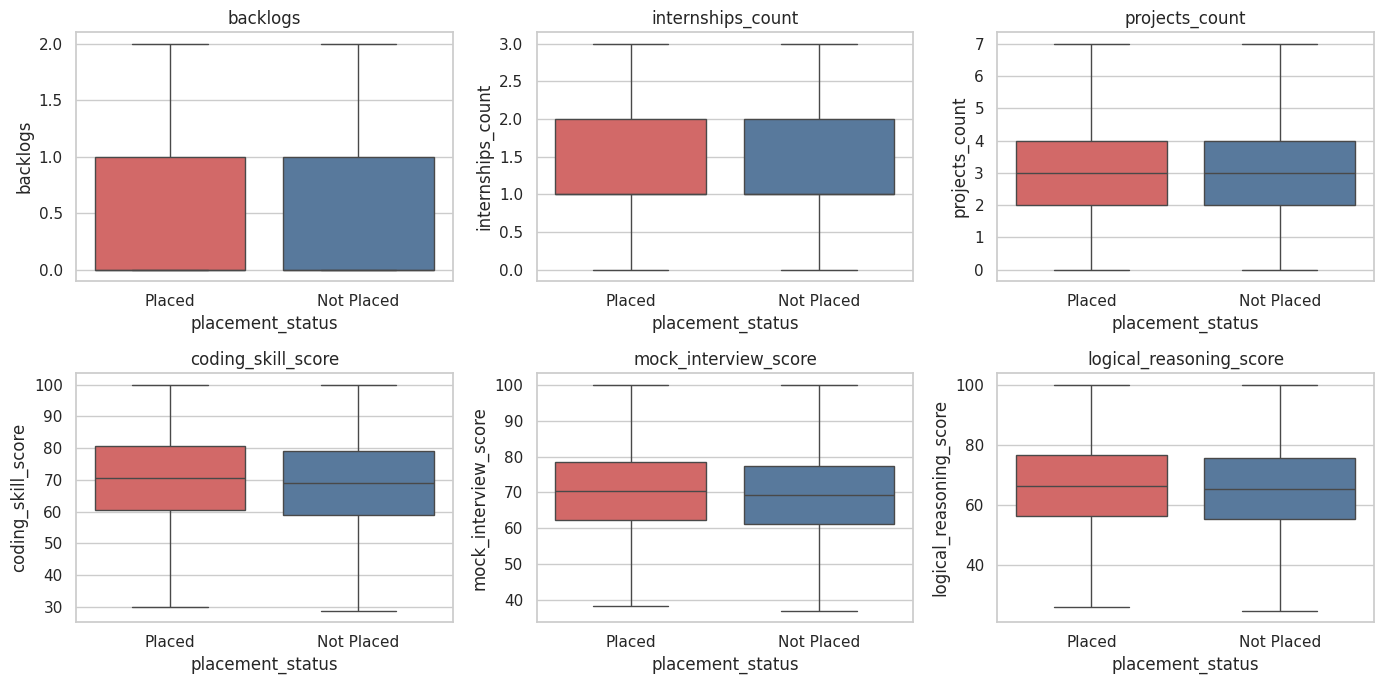

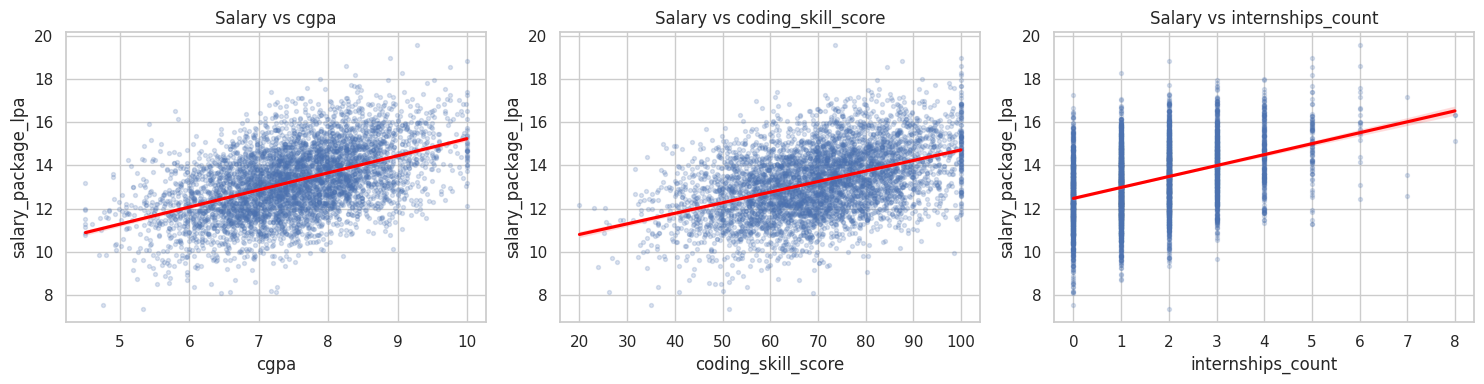

In [10]:
# [EDA] How do the strongest drivers look for placed vs not-placed students?
top = corr_tbl["corr_with_placed"].abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for a, c in zip(axes.ravel(), top):
    sns.boxplot(data=train_df, x="placement_status", y=c, ax=a, palette=["#E45756", "#4C78A8"], showfliers=False)
    a.set_title(c)
savefig("03_top_features_by_status")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(axes, ["cgpa", "coding_skill_score", "internships_count"]):
    sns.regplot(data=train_placed.sample(min(5000, len(train_placed)), random_state=1), x=c, y="salary_package_lpa",
                scatter_kws={"alpha": .2, "s": 8}, line_kws={"color": "red"}, ax=a)
    a.set_title(f"Salary vs {c}")
savefig("04_salary_drivers")

## 4. Feature selection (training data only) — **DATA REDUCTION**

Rules applied, in order:
1. **Drop identifiers** – `student_id` carries no information.
2. **Drop protected attributes** – `gender` and `age` are excluded *on ethical grounds*: a placement tool should not
   score people using them, whatever the data says.
3. **Statistical relevance test** for every remaining column against each target
   (ANOVA-F for numeric→placed, χ² for categorical→placed, Pearson-F for numeric→salary, ANOVA for categorical→salary).
   Keep a feature only if p < `ALPHA` (0.001). Mutual information is shown as a second opinion.
4. **Ablation check** (next section) confirms that dropping the rest did not hurt performance.

In [11]:
# [DATA REDUCTION - part 1] Define candidates: remove IDs, outcome columns and protected attributes.
ID_COLS      = ["student_id"]
PROTECTED    = ["gender", "age"]
OUTCOME_COLS = ["placement_status", "salary_package_lpa", "placed"]

CANDIDATES = [c for c in train_df.columns if c not in ID_COLS + PROTECTED + OUTCOME_COLS]
num_c = [c for c in CANDIDATES if pd.api.types.is_numeric_dtype(train_df[c])]
cat_c = [c for c in CANDIDATES if c not in num_c]
print("Candidate numeric    :", num_c)
print("Candidate categorical:", cat_c)

Candidate numeric    : ['cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day']
Candidate categorical: ['branch', 'college_tier', 'volunteer_experience']


In [12]:
# [DATA REDUCTION - part 2] Statistical relevance tests, computed on TRAIN ONLY.
def encode_for_mi(d):
    # Ordinal-encode categoricals purely for the mutual-information estimate (not used for modelling).
    X = d[CANDIDATES].copy()
    for c in cat_c:
        X[c] = X[c].astype("category").cat.codes
    return X

disc = [c in cat_c for c in CANDIDATES]

# ---- Classification: which columns relate to `placed`? ----
p_cls = {}
for c in num_c:
    p_cls[c] = f_classif(train_df[[c]], train_df["placed"])[1][0]
for c in cat_c:
    p_cls[c] = stats.chi2_contingency(pd.crosstab(train_df[c], train_df["placed"]))[1]
mi_cls = dict(zip(CANDIDATES, mutual_info_classif(encode_for_mi(train_df), train_df["placed"],
                                                 discrete_features=disc, random_state=RANDOM_STATE)))

# ---- Regression (placed only): which columns relate to salary? ----
p_reg = {}
for c in num_c:
    p_reg[c] = f_regression(train_placed[[c]], train_placed["salary_package_lpa"])[1][0]
for c in cat_c:
    groups = [g["salary_package_lpa"].values for _, g in train_placed.groupby(c)]
    p_reg[c] = stats.f_oneway(*groups)[1]
mi_reg = dict(zip(CANDIDATES, mutual_info_regression(encode_for_mi(train_placed), train_placed["salary_package_lpa"],
                                                    discrete_features=disc, random_state=RANDOM_STATE)))

fs_table = pd.DataFrame({
    "p_value_placement": pd.Series(p_cls), "MI_placement": pd.Series(mi_cls),
    "p_value_salary":    pd.Series(p_reg), "MI_salary":    pd.Series(mi_reg),
}).sort_values("p_value_placement")
fs_table["keep_for_placement"] = fs_table["p_value_placement"] < ALPHA
fs_table["keep_for_salary"]    = fs_table["p_value_salary"] < ALPHA
fs_table.to_csv(DIRS["reports"] / "feature_selection_table.csv")
display(fs_table.style.format({"p_value_placement": "{:.2e}", "p_value_salary": "{:.2e}",
                               "MI_placement": "{:.4f}", "MI_salary": "{:.4f}"}))

,p_value_placement,MI_placement,p_value_salary,MI_salary,keep_for_placement,keep_for_salary
backlogs,8.76e-127,0.0073,8.99e-02,0.0000,True,False
internships_count,1.44e-68,0.0058,0.00e+00,0.0854,True,True
projects_count,1.04e-65,0.0026,6.79e-02,0.0007,True,False
coding_skill_score,7.16e-48,0.0018,0.00e+00,0.1160,True,True
mock_interview_score,8.60e-39,0.0009,3.46e-01,0.0000,True,False
logical_reasoning_score,5.90e-24,0.0025,7.57e-01,0.0027,True,False
aptitude_score,1.05e-19,0.0000,9.51e-01,0.0000,True,False
communication_skill_score,9.65e-18,0.0000,9.26e-01,0.0021,True,False
leadership_score,7.78e-11,0.0000,3.90e-01,0.0000,True,False
extracurricular_score,9.87e-09,0.0017,7.28e-02,0.0078,True,False


In [13]:
# [DATA REDUCTION - relationship strength] p-values only say an effect exists; effect sizes say how big. Report-only: the keep/drop rule is unchanged.
def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    return float(np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1))))

def eta_corr(groups, y):
    ssb = sum(len(v) * (v.mean() - y.mean()) ** 2 for _, v in y.groupby(groups))
    return float(np.sqrt(ssb / ((y - y.mean()) ** 2).sum()))

def strength(v):
    return "negligible" if v < 0.02 else "very weak" if v < 0.05 else "weak" if v < 0.10 else "moderate" if v < 0.30 else "strong"

eff_p, eff_s = {}, {}
for c in num_c:
    eff_p[c] = abs(train_df[c].corr(train_df["placed"]))
    eff_s[c] = abs(train_placed[c].corr(train_placed["salary_package_lpa"]))
for c in cat_c:
    eff_p[c] = cramers_v(train_df[c], train_df["placed"])
    eff_s[c] = eta_corr(train_placed[c], train_placed["salary_package_lpa"])

fs_table["effect_placement"] = pd.Series(eff_p)
fs_table["strength_placement"] = fs_table["effect_placement"].map(strength)
fs_table["effect_salary"] = pd.Series(eff_s)
fs_table["strength_salary"] = fs_table["effect_salary"].map(strength)
fs_table.to_csv(DIRS["reports"] / "feature_selection_table.csv")

cols = ["effect_placement", "strength_placement", "keep_for_placement", "effect_salary", "strength_salary", "keep_for_salary"]
display(fs_table[cols].sort_values("effect_salary", ascending=False))

,effect_placement,strength_placement,keep_for_placement,effect_salary,strength_salary,keep_for_salary
cgpa,0.013820,negligible,True,0.502891,strong,True
coding_skill_score,0.051359,weak,True,0.455294,strong,True
internships_count,0.061812,weak,True,0.389635,strong,True
projects_count,0.060476,weak,True,0.008746,negligible,False
extracurricular_score,0.020267,very weak,True,0.008596,negligible,False
backlogs,0.084534,weak,True,0.008125,negligible,False
mock_interview_score,0.046034,very weak,True,0.004512,negligible,False
linkedin_connections,0.003535,negligible,False,0.004246,negligible,False
leadership_score,0.022995,very weak,True,0.004115,negligible,False
hackathons_participated,0.003864,negligible,False,0.003352,negligible,False


In [14]:
# [DATA REDUCTION - part 3] Final feature lists (order kept as in the original dataset).
CLS_FEATURES = [c for c in CANDIDATES if fs_table.loc[c, "keep_for_placement"]]
REG_FEATURES = [c for c in CANDIDATES if fs_table.loc[c, "keep_for_salary"]]
assert len(CLS_FEATURES) >= 3 and len(REG_FEATURES) >= 2, "Feature selection kept too few columns - check ALPHA."

print(f"Placement classifier uses {len(CLS_FEATURES)} of {len(CANDIDATES)} candidates:\n  ", CLS_FEATURES)
print(f"Salary regressor uses {len(REG_FEATURES)} of {len(CANDIDATES)} candidates:\n  ", REG_FEATURES)
print("Not used by the placement classifier:", [c for c in CANDIDATES if c not in CLS_FEATURES])
print("Not used by the salary regressor   :", [c for c in CANDIDATES if c not in REG_FEATURES])

Placement classifier uses 11 of 21 candidates:
   ['cgpa', 'internships_count', 'projects_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'mock_interview_score', 'backlogs', 'extracurricular_score', 'leadership_score']
Salary regressor uses 3 of 21 candidates:
   ['cgpa', 'internships_count', 'coding_skill_score']
Not used by the placement classifier: ['branch', 'college_tier', 'certifications_count', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'attendance_percentage', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day']
Not used by the salary regressor   : ['branch', 'college_tier', 'projects_count', 'certifications_count', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_h

## 5. Preprocessing pipeline — **TRANSFORMATION + ENCODING**
Everything is wrapped in one `Pipeline`, so during cross-validation the imputer/scaler/encoder are re-fitted on each
training fold only (**no leakage**):

`FeatureEngineer` (adds features) → `ColumnTransformer` [numeric: median-impute → StandardScaler | categorical: most-frequent-impute → OneHotEncoder] → model

In [15]:
# [TRANSFORMATION + ENCODING] Reusable preprocessing / pipeline factory.
def make_preprocessor():
    num_sel = make_column_selector(dtype_include=np.number)        # numeric columns (incl. engineered ones)
    cat_sel = make_column_selector(dtype_exclude=np.number)        # text columns -> one-hot
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),          # fill missing (none now, but safe in production)
                          ("scale",  StandardScaler())]), num_sel),              # zero-mean / unit-variance
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_sel),   # categorical encoding
    ])

def make_pipe(estimator, use_fe):
    return Pipeline([("fe", FeatureEngineer(add_features=use_fe)),
                     ("prep", make_preprocessor()),
                     ("model", estimator)])

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)   # classification folds
kf  = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)             # regression folds

### 5.1 Ablation: does dropping columns / adding engineered features actually help?
Quick cross-validated check with a plain Logistic Regression (classification) and Ridge (regression), on the training set only.

In [16]:
# [FEATURE ENGINEERING VALIDATION] Compare (a) all candidates, (b) selected only, (c) selected + engineered features.
def cv_score(pipe, X, y, cv, scoring):
    return cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)["test_score"]

rows = []
# --- classification (metric: ROC-AUC) ---
for label, feats, fe in [("all candidates", CANDIDATES, False), ("selected", CLS_FEATURES, False), ("selected + engineered", CLS_FEATURES, True)]:
    s = cv_score(make_pipe(LogisticRegression(max_iter=2000), fe), train_df[feats], train_df["placed"], skf, "roc_auc")
    rows.append(("placement (ROC-AUC)", label, s.mean(), s.std()))
# --- regression (metric: R2) ---
for label, feats, fe in [("all candidates", CANDIDATES, False), ("selected", REG_FEATURES, False), ("selected + engineered", REG_FEATURES, True)]:
    s = cv_score(make_pipe(Ridge(alpha=1.0), fe), train_placed[feats], train_placed["salary_package_lpa"], kf, "r2")
    rows.append(("salary (R2)", label, s.mean(), s.std()))

ablation = pd.DataFrame(rows, columns=["task", "feature set", "cv_mean", "cv_std"])
ablation.to_csv(DIRS["reports"] / "ablation_feature_sets.csv", index=False)
display(ablation.round(4))

# Keep engineered features only if they improved the CV mean for that task.
def pick(task):
    a = ablation[ablation.task == task].set_index("feature set")["cv_mean"]
    return bool(a["selected + engineered"] > a["selected"])
USE_FE_CLS, USE_FE_REG = pick("placement (ROC-AUC)"), pick("salary (R2)")
print("Use engineered features -> classifier:", USE_FE_CLS, "| regressor:", USE_FE_REG)

,task,feature set,cv_mean,cv_std
0,placement (ROC-AUC),all candidates,0.5852,0.0039
1,placement (ROC-AUC),selected,0.5856,0.0045
2,placement (ROC-AUC),selected + engineered,0.5856,0.0045
3,salary (R2),all candidates,0.6090,0.0049
4,salary (R2),selected,0.6092,0.0050
5,salary (R2),selected + engineered,0.6092,0.0050


Use engineered features -> classifier: False | regressor: False


## 6. Stage 1 — Placement classification: four models

Hyper-parameters are tuned by randomized search on a **subsample of the training data** with inner cross-validation
(speed); the tuned models are then compared with a full stratified K-fold CV on the whole training set.

In [17]:
# [MODELLING] Helper: hyper-parameter search on a training subsample (never touches the test set).
def tune(name, pipe, space, X, y, cv, scoring, grid=False):
    idx = X.sample(min(TUNE_SAMPLE, len(X)), random_state=RANDOM_STATE).index
    Xs, ys = X.loc[idx], y.loc[idx]
    if grid:
        s = GridSearchCV(pipe, space, cv=cv, scoring=scoring, n_jobs=1)
    else:
        s = RandomizedSearchCV(pipe, space, n_iter=N_ITER, cv=cv, scoring=scoring, n_jobs=1, random_state=RANDOM_STATE)
    t0 = time.time()
    s.fit(Xs, ys)
    print(f"{name:<22} best CV score on subsample = {s.best_score_:.4f}   ({time.time()-t0:.0f}s)")
    return s.best_estimator_.named_steps["model"], s.best_params_

X_tr, y_tr = train_df[CLS_FEATURES], train_df["placed"]
tune_cv = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)

# 1) Logistic Regression: tune regularisation strength C
lr_cls, lr_params = tune("LogisticRegression", make_pipe(LogisticRegression(max_iter=3000), USE_FE_CLS),
                         {"model__C": [0.01, 0.1, 1, 10]}, X_tr, y_tr, tune_cv, "roc_auc", grid=True)

# 2) Random Forest (shallow trees + large leaves: the data are noisy, so strong regularisation is important)
rf_cls, rf_params = tune("RandomForest", make_pipe(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), USE_FE_CLS),
                         {"model__n_estimators": [150, 250, 350], "model__max_depth": [4, 6, 8, 10],
                          "model__min_samples_leaf": [10, 25, 50, 100], "model__max_features": ["sqrt", 0.5, 0.8]},
                         X_tr, y_tr, tune_cv, "roc_auc")

# 3) XGBoost
xgb_cls, xgb_params = tune("XGBoost", make_pipe(XGBClassifier(eval_metric="logloss", tree_method="hist", n_jobs=-1,
                                                             random_state=RANDOM_STATE, verbosity=0), USE_FE_CLS),
                           {"model__n_estimators": [100, 200, 300, 400], "model__max_depth": [2, 3, 4, 5],
                            "model__learning_rate": [0.01, 0.03, 0.05, 0.1], "model__subsample": [0.7, 0.85, 1.0],
                            "model__colsample_bytree": [0.6, 0.8, 1.0], "model__min_child_weight": [1, 5, 10, 20],
                            "model__reg_lambda": [1, 5, 10, 20]}, X_tr, y_tr, tune_cv, "roc_auc")

# LightGBM is used as an extra, diverse base learner inside the stack (fixed, regularised settings).
lgbm_cls = LGBMClassifier(n_estimators=250, learning_rate=0.05, num_leaves=15, min_child_samples=50, subsample=0.8,
                          subsample_freq=1, colsample_bytree=0.8, reg_lambda=5, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
print("\nBest params:", {"LR": lr_params, "RF": rf_params, "XGB": xgb_params}, sep="\n")

LogisticRegression     best CV score on subsample = 0.5886   (1s)
RandomForest           best CV score on subsample = 0.5804   (177s)
XGBoost                best CV score on subsample = 0.5822   (10s)

Best params:
{'LR': {'model__C': 0.01}, 'RF': {'model__n_estimators': 250, 'model__min_samples_leaf': 100, 'model__max_features': 'sqrt', 'model__max_depth': 8}, 'XGB': {'model__subsample': 1.0, 'model__reg_lambda': 10, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}}


In [18]:
# [MODELLING] Model 4 = Stacking ensemble. Base learners' out-of-fold probabilities feed a Logistic-Regression meta-learner.
stack_cls = StackingClassifier(
    estimators=[("lr", clone(lr_cls)), ("rf", clone(rf_cls)), ("xgb", clone(xgb_cls)), ("lgbm", clone(lgbm_cls))],
    final_estimator=LogisticRegression(max_iter=2000), stack_method="predict_proba",
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE), n_jobs=1)

cls_models = {   # ordered from simplest to most complex (used by the one-standard-error rule below)
    "1. Logistic Regression": make_pipe(lr_cls, USE_FE_CLS),
    "2. Random Forest":       make_pipe(rf_cls, USE_FE_CLS),
    "3. XGBoost":             make_pipe(xgb_cls, USE_FE_CLS),
    "4. Stacking Ensemble":   make_pipe(stack_cls, USE_FE_CLS),
}

In [19]:
# [EVALUATION - cross-validation on TRAIN] Fair comparison of the four classifiers (+ a "no-skill" reference).
scoring_cls = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1",
               "roc_auc": "roc_auc", "brier": "neg_brier_score"}
cv_rows, cv_raw = [], {}
ref = cross_validate(make_pipe(DummyClassifier(strategy="prior"), False), X_tr, y_tr, cv=skf, scoring=scoring_cls)
cv_rows.append({"model": "(reference) always-predict-prior", **{f"{k}_mean": (-1 if k == "brier" else 1) * ref[f"test_{k}"].mean() for k in scoring_cls},
                **{f"{k}_std": ref[f"test_{k}"].std() for k in scoring_cls}, "train_roc_auc": 0.5, "fit_time_s": 0})

for name, pipe in cls_models.items():
    res = cross_validate(pipe, X_tr, y_tr, cv=skf, scoring=scoring_cls, return_train_score=True, n_jobs=1)
    cv_raw[name] = res
    row = {"model": name}
    for k in scoring_cls:
        sign = -1 if k == "brier" else 1
        row[f"{k}_mean"], row[f"{k}_std"] = sign * res[f"test_{k}"].mean(), res[f"test_{k}"].std()
    row["train_roc_auc"], row["fit_time_s"] = res["train_roc_auc"].mean(), res["fit_time"].mean()
    cv_rows.append(row)
    print(f"{name:<24} CV ROC-AUC = {row['roc_auc_mean']:.4f} ± {row['roc_auc_std']:.4f}  (train {row['train_roc_auc']:.4f})")

cv_cls = pd.DataFrame(cv_rows).set_index("model")
cv_cls.to_csv(DIRS["reports"] / "classification_cv_results.csv")
display(cv_cls.round(4))

1. Logistic Regression   CV ROC-AUC = 0.5856 ± 0.0045  (train 0.5862)
2. Random Forest         CV ROC-AUC = 0.5814 ± 0.0037  (train 0.6261)
3. XGBoost               CV ROC-AUC = 0.5829 ± 0.0041  (train 0.5951)
4. Stacking Ensemble     CV ROC-AUC = 0.5855 ± 0.0044  (train 0.5861)


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,brier_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std,brier_std,train_roc_auc,fit_time_s
model,,,,,,,,,,,,,,
(reference) always-predict-prior,0.5446,0.5446,1.0000,0.7052,0.5000,0.2480,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000
1. Logistic Regression,0.5700,0.5785,0.7754,0.6626,0.5856,0.2422,0.0038,0.0023,0.0065,0.0038,0.0045,0.0007,0.5862,0.1457
2. Random Forest,0.5679,0.5699,0.8422,0.6798,0.5814,0.2432,0.0025,0.0011,0.0068,0.0030,0.0037,0.0004,0.6261,13.9367
3. XGBoost,0.5689,0.5735,0.8133,0.6727,0.5829,0.2427,0.0030,0.0018,0.0059,0.0030,0.0041,0.0005,0.5951,0.7925
4. Stacking Ensemble,0.5697,0.5780,0.7777,0.6631,0.5855,0.2422,0.0034,0.0019,0.0064,0.0035,0.0044,0.0006,0.5861,46.8500


Best by mean CV AUC : 1. Logistic Regression
Selected (1-SE rule): 1. Logistic Regression


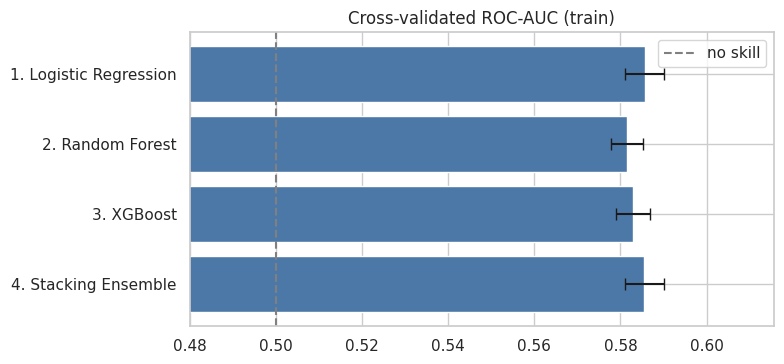

In [20]:
# [MODEL SELECTION] One-standard-error rule: among models whose CV ROC-AUC is within 1 std of the best,
# choose the SIMPLEST. (If a complex model is only statistically tied, complexity buys nothing.)
auc = cv_cls.loc[list(cls_models), ["roc_auc_mean", "roc_auc_std"]]
best_name = auc["roc_auc_mean"].idxmax()
threshold = auc.loc[best_name, "roc_auc_mean"] - auc.loc[best_name, "roc_auc_std"]
FINAL_CLS_NAME = next(n for n in cls_models if auc.loc[n, "roc_auc_mean"] >= threshold)   # dict is ordered simple -> complex
print(f"Best by mean CV AUC : {best_name}")
print(f"Selected (1-SE rule): {FINAL_CLS_NAME}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(auc.index[::-1], auc["roc_auc_mean"][::-1], xerr=auc["roc_auc_std"][::-1], color="#4C78A8", capsize=4)
ax.axvline(0.5, color="grey", ls="--", label="no skill"); ax.set_xlim(0.48, auc["roc_auc_mean"].max() + 0.03)
ax.set_title("Cross-validated ROC-AUC (train)"); ax.legend()
savefig("05_cls_cv_auc")

### 6.1 Final evaluation on the untouched test set

In [21]:
# [EVALUATION - TEST SET, used once] Fit each model on the FULL training set, score on the locked test set.
def cls_metrics(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {"accuracy": accuracy_score(y_true, pred), "precision": precision_score(y_true, pred),
            "recall": recall_score(y_true, pred), "f1": f1_score(y_true, pred),
            "roc_auc": roc_auc_score(y_true, proba), "pr_auc": average_precision_score(y_true, proba),
            "brier": brier_score_loss(y_true, proba), "log_loss": log_loss(y_true, proba)}

X_te, y_te = test_df[CLS_FEATURES], test_df["placed"]
fitted_cls, test_proba, test_rows = {}, {}, []
for name, pipe in cls_models.items():
    m = clone(pipe).fit(X_tr, y_tr)
    fitted_cls[name] = m
    test_proba[name] = m.predict_proba(X_te)[:, 1]
    test_rows.append({"model": name, **cls_metrics(y_te, test_proba[name])})

test_cls = pd.DataFrame(test_rows).set_index("model")
test_cls.to_csv(DIRS["reports"] / "classification_test_results.csv")
display(test_cls.round(4).style.highlight_max(axis=0, color="#c7f0c7", subset=["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"])
                                .highlight_min(axis=0, color="#c7f0c7", subset=["brier", "log_loss"]))

,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,log_loss
model,,,,,,,,
1. Logistic Regression,0.572100,0.580100,0.776300,0.664000,0.586000,0.620000,0.242200,0.677400
2. Random Forest,0.566000,0.568600,0.842200,0.678800,0.580200,0.615300,0.243200,0.679400
3. XGBoost,0.567400,0.572200,0.814600,0.672200,0.583000,0.617200,0.242700,0.678300
4. Stacking Ensemble,0.571500,0.579200,0.779200,0.664500,0.585700,0.619800,0.242300,0.677400


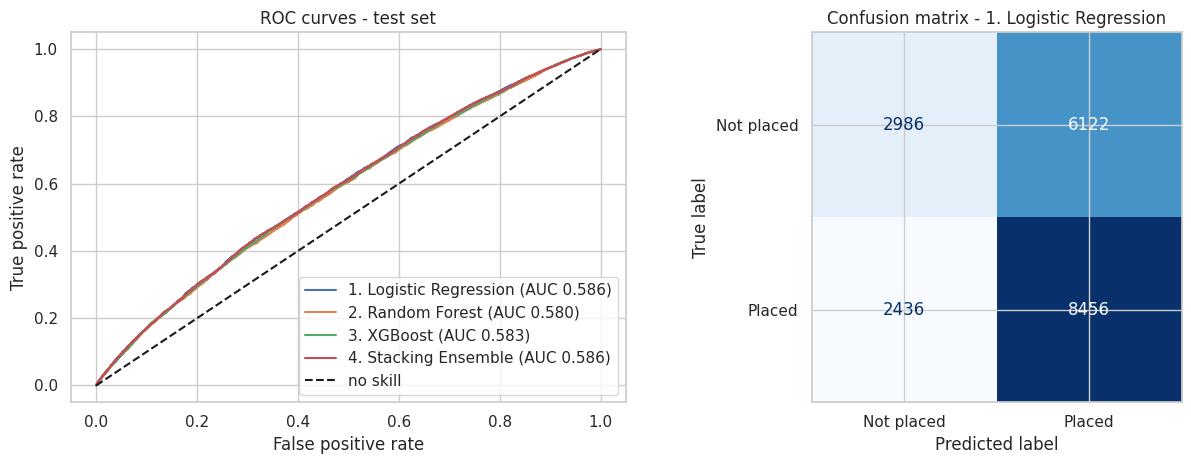

In [22]:
# [EVALUATION - plots] ROC curves and confusion matrix of the selected model.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for name, p in test_proba.items():
    fpr, tpr, _ = roc_curve(y_te, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te, p):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", label="no skill"); ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curves - test set"); ax[0].legend(loc="lower right")
ConfusionMatrixDisplay(confusion_matrix(y_te, (test_proba[FINAL_CLS_NAME] >= 0.5).astype(int)),
                       display_labels=["Not placed", "Placed"]).plot(ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title(f"Confusion matrix - {FINAL_CLS_NAME}")
savefig("06_cls_roc_confusion")

### 6.2 Innovation: probability calibration
A model's raw score is not automatically a *probability*. We test whether wrapping the selected model in `CalibratedClassifierCV`
(isotonic, fitted **on training data only**) improves the out-of-fold Brier score. It is applied only if it does; otherwise the raw model is
kept (logistic regression is usually already well calibrated).

Train out-of-fold Brier  raw = 0.2422 | calibrated = 0.2422 -> calibration applied: False


,roc_auc,brier,log_loss,accuracy
raw,0.5860,0.2422,0.6774,0.5721
calibrated,0.5857,0.2424,0.6781,0.5714


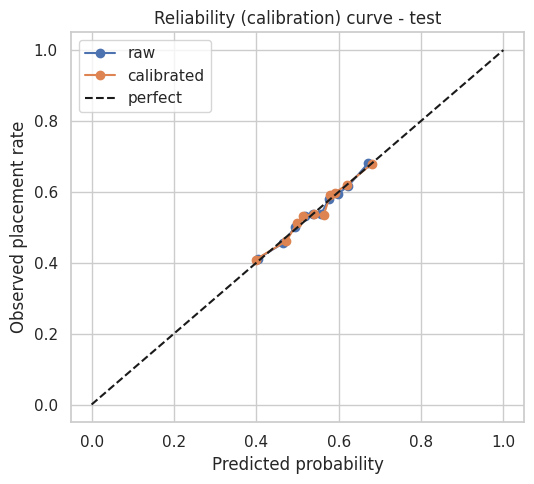

In [23]:
# [CALIBRATION] Decide on TRAIN out-of-fold Brier score whether isotonic calibration helps; deploy the raw model if it does not.
from sklearn.model_selection import cross_val_predict
raw_final = clone(cls_models[FINAL_CLS_NAME])
calibrated_cls = CalibratedClassifierCV(estimator=clone(raw_final), method="isotonic",
                                        cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE))
oof_raw = cross_val_predict(clone(raw_final), X_tr, y_tr, cv=skf, method="predict_proba")[:, 1]
oof_cal = cross_val_predict(clone(calibrated_cls), X_tr, y_tr, cv=skf, method="predict_proba")[:, 1]
brier_raw, brier_cal = brier_score_loss(y_tr, oof_raw), brier_score_loss(y_tr, oof_cal)
USE_CALIBRATION = bool(brier_cal < brier_raw - 0.0005)
print(f"Train out-of-fold Brier  raw = {brier_raw:.4f} | calibrated = {brier_cal:.4f} -> calibration applied: {USE_CALIBRATION}")

calibrated_cls.fit(X_tr, y_tr)
final_classifier = calibrated_cls if USE_CALIBRATION else fitted_cls[FINAL_CLS_NAME]
p_raw = test_proba[FINAL_CLS_NAME]
p_cal = calibrated_cls.predict_proba(X_te)[:, 1]
p_final = final_classifier.predict_proba(X_te)[:, 1]
calib_cmp = pd.DataFrame({"raw": cls_metrics(y_te, p_raw), "calibrated": cls_metrics(y_te, p_cal)}).T
display(calib_cmp[["roc_auc", "brier", "log_loss", "accuracy"]].round(4))

fig, ax = plt.subplots(figsize=(5.5, 5))
for lab, p in [("raw", p_raw), ("calibrated", p_cal)]:
    fp, mp = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    ax.plot(mp, fp, marker="o", label=lab)
ax.plot([0, 1], [0, 1], "k--", label="perfect"); ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed placement rate")
ax.set_title("Reliability (calibration) curve - test"); ax.legend()
savefig("07_calibration")


## 7. Stage 2 — Salary regression (placed students only): four models
Same four-model ladder: **Ridge → Random Forest → XGBoost → Stacking**. Salary is only defined for placed students,
so the regressor is trained and evaluated on that subset; the combined system (Section 9) then multiplies by the placement probability.

In [24]:
# [MODELLING - regression] Tune, then build the four regressors.
Xr_tr, yr_tr = train_placed[REG_FEATURES], train_placed["salary_package_lpa"]
Xr_te, yr_te = test_placed[REG_FEATURES],  test_placed["salary_package_lpa"]
tune_kf = KFold(3, shuffle=True, random_state=RANDOM_STATE)

ridge_reg, ridge_p = tune("Ridge", make_pipe(Ridge(), USE_FE_REG), {"model__alpha": [0.01, 0.1, 1, 10, 100]},
                          Xr_tr, yr_tr, tune_kf, "neg_root_mean_squared_error", grid=True)
rf_reg, rf_p = tune("RandomForestRegressor", make_pipe(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), USE_FE_REG),
                    {"model__n_estimators": [150, 250, 350], "model__max_depth": [4, 6, 8, 10],
                     "model__min_samples_leaf": [5, 10, 25, 50], "model__max_features": ["sqrt", 0.5, 0.8, 1.0]},
                    Xr_tr, yr_tr, tune_kf, "neg_root_mean_squared_error")
xgb_reg, xgb_p = tune("XGBRegressor", make_pipe(XGBRegressor(tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE, verbosity=0), USE_FE_REG),
                      {"model__n_estimators": [100, 200, 300, 400], "model__max_depth": [2, 3, 4, 5],
                       "model__learning_rate": [0.01, 0.03, 0.05, 0.1], "model__subsample": [0.7, 0.85, 1.0],
                       "model__colsample_bytree": [0.6, 0.8, 1.0], "model__min_child_weight": [1, 5, 10, 20],
                       "model__reg_lambda": [1, 5, 10, 20]}, Xr_tr, yr_tr, tune_kf, "neg_root_mean_squared_error")
lgbm_reg = LGBMRegressor(n_estimators=250, learning_rate=0.05, num_leaves=15, min_child_samples=50, subsample=0.8,
                         subsample_freq=1, colsample_bytree=0.8, reg_lambda=5, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

stack_reg = StackingRegressor(
    estimators=[("ridge", clone(ridge_reg)), ("rf", clone(rf_reg)), ("xgb", clone(xgb_reg)), ("lgbm", clone(lgbm_reg))],
    final_estimator=Ridge(alpha=1.0), cv=KFold(3, shuffle=True, random_state=RANDOM_STATE), n_jobs=1)

reg_models = {
    "1. Ridge Regression": make_pipe(ridge_reg, USE_FE_REG),
    "2. Random Forest":    make_pipe(rf_reg, USE_FE_REG),
    "3. XGBoost":          make_pipe(xgb_reg, USE_FE_REG),
    "4. Stacking Ensemble":make_pipe(stack_reg, USE_FE_REG),
}
print("\nBest params:", {"Ridge": ridge_p, "RF": rf_p, "XGB": xgb_p}, sep="\n")

Ridge                  best CV score on subsample = -0.9957   (0s)
RandomForestRegressor  best CV score on subsample = -1.0095   (52s)
XGBRegressor           best CV score on subsample = -0.9997   (6s)

Best params:
{'Ridge': {'model__alpha': 1}, 'RF': {'model__n_estimators': 250, 'model__min_samples_leaf': 10, 'model__max_features': 1.0, 'model__max_depth': 8}, 'XGB': {'model__subsample': 1.0, 'model__reg_lambda': 10, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}}


In [25]:
# [EVALUATION - cross-validation on TRAIN] Regression comparison (MAE / RMSE in LPA, R2).
scoring_reg = {"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"}
rows = []
base = cross_validate(make_pipe(DummyRegressor(strategy="mean"), False),
                      Xr_tr, yr_tr, cv=kf, scoring=scoring_reg)
rows.append({"model": "(reference) always-predict-mean", "mae_mean": -base["test_mae"].mean(), "mae_std": base["test_mae"].std(),
             "rmse_mean": -base["test_rmse"].mean(), "rmse_std": base["test_rmse"].std(), "r2_mean": base["test_r2"].mean(),
             "r2_std": base["test_r2"].std(), "train_r2": 0.0, "fit_time_s": 0})
for name, pipe in reg_models.items():
    res = cross_validate(pipe, Xr_tr, yr_tr, cv=kf, scoring=scoring_reg, return_train_score=True, n_jobs=1)
    rows.append({"model": name, "mae_mean": -res["test_mae"].mean(), "mae_std": res["test_mae"].std(),
                 "rmse_mean": -res["test_rmse"].mean(), "rmse_std": res["test_rmse"].std(),
                 "r2_mean": res["test_r2"].mean(), "r2_std": res["test_r2"].std(),
                 "train_r2": res["train_r2"].mean(), "fit_time_s": res["fit_time"].mean()})
    print(f"{name:<24} CV RMSE = {rows[-1]['rmse_mean']:.4f} ± {rows[-1]['rmse_std']:.4f} LPA | R2 = {rows[-1]['r2_mean']:.4f}")
cv_reg = pd.DataFrame(rows).set_index("model")
cv_reg.to_csv(DIRS["reports"] / "regression_cv_results.csv")
display(cv_reg.round(4))

# One-standard-error rule on RMSE (lower is better): simplest model within 1 std of the best.
rm = cv_reg.loc[list(reg_models), ["rmse_mean", "rmse_std"]]
best_r = rm["rmse_mean"].idxmin()
limit = rm.loc[best_r, "rmse_mean"] + rm.loc[best_r, "rmse_std"]
FINAL_REG_NAME = next(n for n in reg_models if rm.loc[n, "rmse_mean"] <= limit)
print(f"\nBest by mean CV RMSE: {best_r}\nSelected (1-SE rule): {FINAL_REG_NAME}")

1. Ridge Regression      CV RMSE = 0.9967 ± 0.0057 LPA | R2 = 0.6092
2. Random Forest         CV RMSE = 1.0084 ± 0.0066 LPA | R2 = 0.5999
3. XGBoost               CV RMSE = 0.9998 ± 0.0057 LPA | R2 = 0.6068
4. Stacking Ensemble     CV RMSE = 0.9967 ± 0.0057 LPA | R2 = 0.6092


,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,train_r2,fit_time_s
model,,,,,,,,
(reference) always-predict-mean,1.2766,0.0059,1.5944,0.0048,-0.0001,0.0001,0.0000,0.0000
1. Ridge Regression,0.7967,0.0053,0.9967,0.0057,0.6092,0.0050,0.6093,0.0203
2. Random Forest,0.8056,0.0056,1.0084,0.0066,0.5999,0.0054,0.6241,4.8341
3. XGBoost,0.7988,0.0054,0.9998,0.0057,0.6068,0.0048,0.6100,0.2881
4. Stacking Ensemble,0.7967,0.0052,0.9967,0.0057,0.6092,0.0049,0.6085,17.4429



Best by mean CV RMSE: 1. Ridge Regression
Selected (1-SE rule): 1. Ridge Regression


,mae_lpa,rmse_lpa,r2
model,,,
1. Ridge Regression,0.795800,0.998400,0.602900
2. Random Forest,0.804600,1.010100,0.593500
3. XGBoost,0.798500,1.001500,0.600400
4. Stacking Ensemble,0.795900,0.998500,0.602800


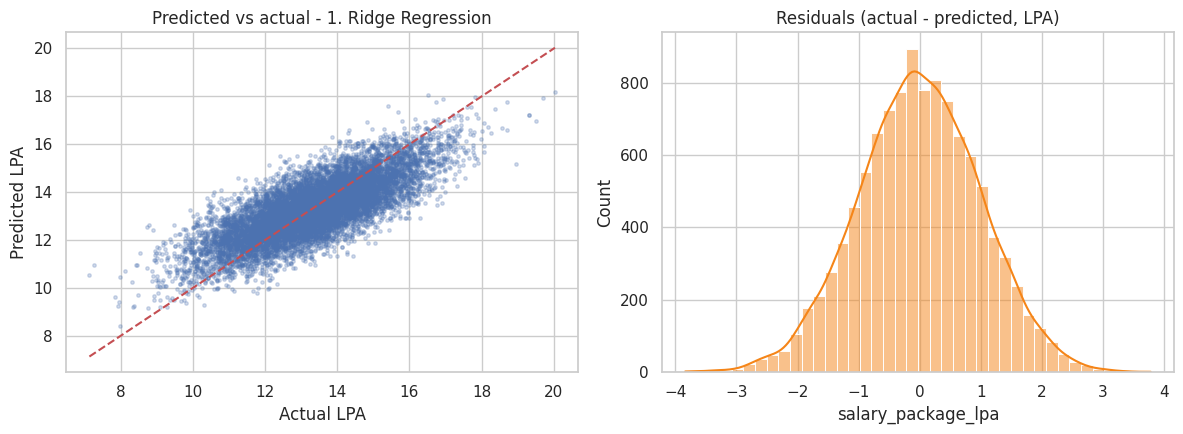

In [26]:
# [EVALUATION - TEST SET, used once] Fit all four regressors on the full training set, score on test (placed students).
def reg_metrics(y_true, pred):
    return {"mae_lpa": mean_absolute_error(y_true, pred), "rmse_lpa": mean_squared_error(y_true, pred) ** 0.5, "r2": r2_score(y_true, pred)}

fitted_reg, reg_pred, rows = {}, {}, []
for name, pipe in reg_models.items():
    m = clone(pipe).fit(Xr_tr, yr_tr)
    fitted_reg[name] = m
    reg_pred[name] = m.predict(Xr_te)
    rows.append({"model": name, **reg_metrics(yr_te, reg_pred[name])})
test_reg = pd.DataFrame(rows).set_index("model")
test_reg.to_csv(DIRS["reports"] / "regression_test_results.csv")
display(test_reg.round(4).style.highlight_min(axis=0, color="#c7f0c7", subset=["mae_lpa", "rmse_lpa"]).highlight_max(axis=0, color="#c7f0c7", subset=["r2"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
p = reg_pred[FINAL_REG_NAME]
ax[0].scatter(yr_te, p, s=6, alpha=.25); lim = [yr_te.min(), yr_te.max()]; ax[0].plot(lim, lim, "r--")
ax[0].set_xlabel("Actual LPA"); ax[0].set_ylabel("Predicted LPA"); ax[0].set_title(f"Predicted vs actual - {FINAL_REG_NAME}")
sns.histplot(yr_te - p, bins=40, kde=True, ax=ax[1], color="#F58518"); ax[1].set_title("Residuals (actual - predicted, LPA)")
savefig("08_reg_pred_vs_actual")

### 7.1 Innovation: salary *range* with quantile regression
A single number ("₹13.4 L") hides uncertainty. Two LightGBM **quantile** models (10th and 90th percentile) give an
80 % prediction band. We check that the band really covers ≈ 80 % of unseen students.

In [27]:
# [INNOVATION] Quantile regression for a salary range; coverage verified on the test set.
def make_q(alpha):
    return make_pipe(LGBMRegressor(objective="quantile", alpha=alpha, n_estimators=300, learning_rate=0.05, num_leaves=8,
                                   min_child_samples=50, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), USE_FE_REG)
q10 = make_q(0.10).fit(Xr_tr, yr_tr)
q90 = make_q(0.90).fit(Xr_tr, yr_tr)
lo, hi = q10.predict(Xr_te), q90.predict(Xr_te)
point = fitted_reg[FINAL_REG_NAME].predict(Xr_te)
lo, hi = np.minimum(lo, point), np.maximum(hi, point)
coverage = np.mean((yr_te >= lo) & (yr_te <= hi))
print(f"80% band coverage on test: {coverage:.3f} (target 0.80) | mean band width: {np.mean(hi - lo):.2f} LPA")

80% band coverage on test: 0.793 (target 0.80) | mean band width: 2.54 LPA


## 8. Refit the selected regressor / classifier for deployment
The classifier is the one chosen in Section 6.2 (calibrated only if calibration helped). The regressor is the selected model refit on the full training set (already done above).

In [28]:
# [FINALISE] Final deployable objects.
final_regressor  = fitted_reg[FINAL_REG_NAME]
print("Final classifier :", FINAL_CLS_NAME, "(isotonic-calibrated)" if USE_CALIBRATION else "(raw, calibration not needed)")
print("Final regressor  :", FINAL_REG_NAME)

Final classifier : 1. Logistic Regression (raw, calibration not needed)
Final regressor  : 1. Ridge Regression


## 9. Combined system on the full test set
`Expected LPA = P(placed) × salary-if-placed`. This is compared with what students *actually* earned (0 for unplaced).
The combined error is naturally larger than the salary-only error: whether a student gets placed at all is only weakly predictable from these features.

,mae_lpa,rmse_lpa,r2
expected-LPA system,6.405,6.579,0.045
naive: predict train mean,6.604,6.733,-0.000


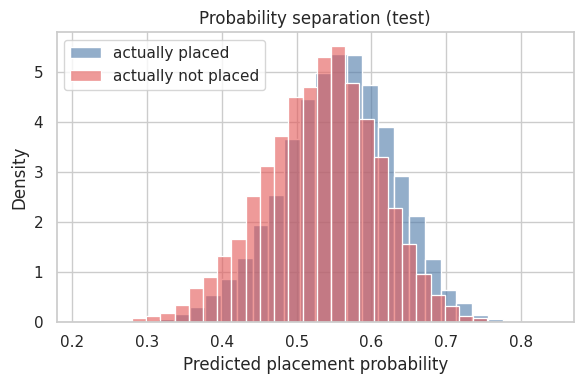

In [29]:
# [EVALUATION - end-to-end] Expected LPA for ALL test students vs their realised salary (0 if not placed).
p_place = final_classifier.predict_proba(test_df[CLS_FEATURES])[:, 1]
sal_hat = np.clip(final_regressor.predict(test_df[REG_FEATURES]), 0, None)
expected = p_place * sal_hat
actual   = test_df["salary_package_lpa"].values
naive    = np.full_like(actual, train_df["salary_package_lpa"].mean(), dtype=float)   # predict the training mean for everyone

e2e = pd.DataFrame({"expected-LPA system": reg_metrics(actual, expected), "naive: predict train mean": reg_metrics(actual, naive)}).T
display(e2e.round(3))

plt.figure(figsize=(6, 4))
sns.histplot(p_place[y_te == 1], color="#4C78A8", label="actually placed", stat="density", bins=30, alpha=.6)
sns.histplot(p_place[y_te == 0], color="#E45756", label="actually not placed", stat="density", bins=30, alpha=.6)
plt.xlabel("Predicted placement probability"); plt.legend(); plt.title("Probability separation (test)")
savefig("09_probability_separation")

### 9.1 How much does the placement model really separate students?
The end-to-end R² above is low because *whether* a student is placed is only weakly predictable here. Three numbers make that concrete
(and the frontend can show them honestly): a bootstrap confidence interval for the test AUC, the placement rate of the highest vs lowest
predicted-probability decile, and how wide the predicted probabilities actually spread.

{
  "test_auc": 0.5860062306147585,
  "auc_ci95": [
    0.5790525910577504,
    0.593733828366678
  ],
  "placement_rate_lowest_decile": 0.4115,
  "placement_rate_highest_decile": 0.6815,
  "prob_p05": 0.4124199403733135,
  "prob_p95": 0.6650142009597597,
  "reliability_note": "Placement is only weakly predictable from these features (AUC 0.59, 95% CI 0.58-0.59). Predicted chances span just 41%-67% for 90% of students; use them as a rough guide, and treat the salary estimate as the more reliable output."
}


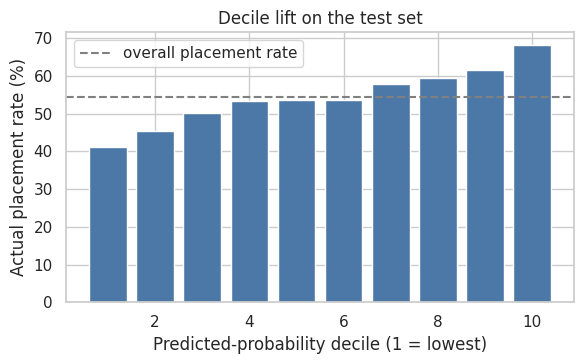

In [30]:
# [HONESTY CHECK] Bootstrap CI for test AUC, decile lift and probability spread (test set, evaluation only).
rng = np.random.default_rng(RANDOM_STATE)
yb, pb = y_te.values, p_place
boot = [roc_auc_score(yb[i], pb[i]) for i in (rng.integers(0, len(yb), len(yb)) for _ in range(300))]
auc_lo, auc_hi = np.percentile(boot, [2.5, 97.5])
decile = pd.qcut(pd.Series(pb).rank(method="first"), 10, labels=False)
lift = pd.Series(yb).groupby(decile.values).mean()
signal_summary = {
    "test_auc": float(roc_auc_score(yb, pb)), "auc_ci95": [float(auc_lo), float(auc_hi)],
    "placement_rate_lowest_decile": float(lift.iloc[0]), "placement_rate_highest_decile": float(lift.iloc[-1]),
    "prob_p05": float(np.percentile(pb, 5)), "prob_p95": float(np.percentile(pb, 95)),
}
signal_summary["reliability_note"] = (
    f"Placement is only weakly predictable from these features (AUC {signal_summary['test_auc']:.2f}, "
    f"95% CI {auc_lo:.2f}-{auc_hi:.2f}). Predicted chances span just {100*signal_summary['prob_p05']:.0f}%-{100*signal_summary['prob_p95']:.0f}% "
    f"for 90% of students; use them as a rough guide, and treat the salary estimate as the more reliable output.")
print(json.dumps(signal_summary, indent=2))

plt.figure(figsize=(6, 3.8))
plt.bar(range(1, 11), 100 * lift.values, color="#4C78A8")
plt.axhline(100 * yb.mean(), color="grey", ls="--", label="overall placement rate")
plt.xlabel("Predicted-probability decile (1 = lowest)"); plt.ylabel("Actual placement rate (%)"); plt.legend()
plt.title("Decile lift on the test set")
savefig("13_decile_lift")

## 10. Explainability (why does the model say that?)

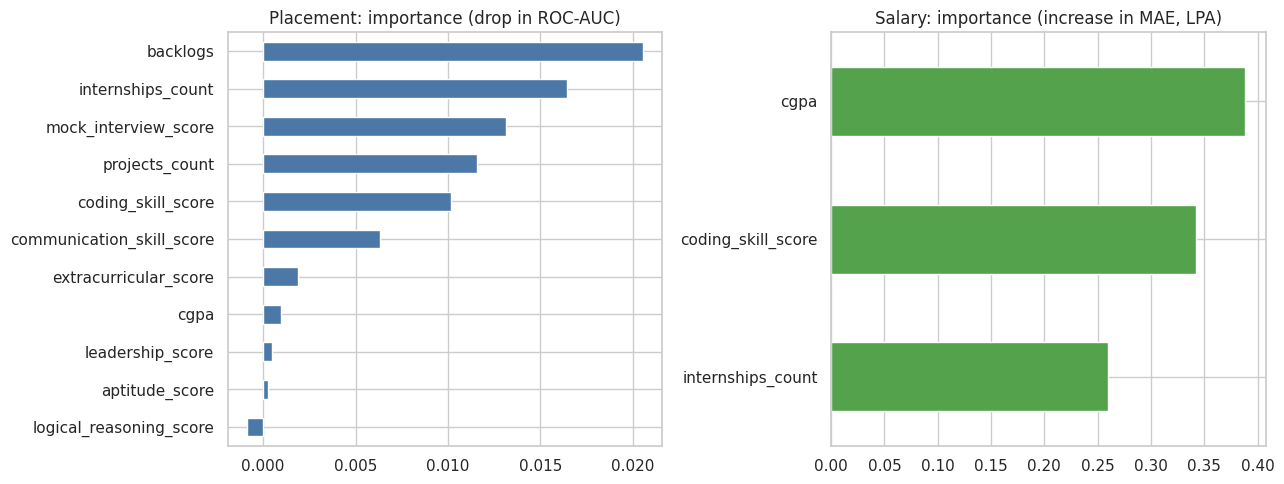

In [31]:
# [EXPLAINABILITY 1] Model-agnostic permutation importance on the test set (drop in score when a feature is shuffled).
samp = test_df.sample(min(4000, len(test_df)), random_state=1)
pi_c = permutation_importance(final_classifier, samp[CLS_FEATURES], samp["placed"], scoring="roc_auc", n_repeats=5, random_state=1, n_jobs=1)
sp = test_placed.sample(min(4000, len(test_placed)), random_state=1)
pi_r = permutation_importance(final_regressor, sp[REG_FEATURES], sp["salary_package_lpa"], scoring="neg_mean_absolute_error", n_repeats=5, random_state=1, n_jobs=1)

imp_c = pd.Series(pi_c.importances_mean, index=CLS_FEATURES).sort_values()
imp_r = pd.Series(pi_r.importances_mean, index=REG_FEATURES).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
imp_c.plot.barh(ax=ax[0], color="#4C78A8"); ax[0].set_title("Placement: importance (drop in ROC-AUC)")
imp_r.plot.barh(ax=ax[1], color="#54A24B"); ax[1].set_title("Salary: importance (increase in MAE, LPA)")
savefig("10_permutation_importance")

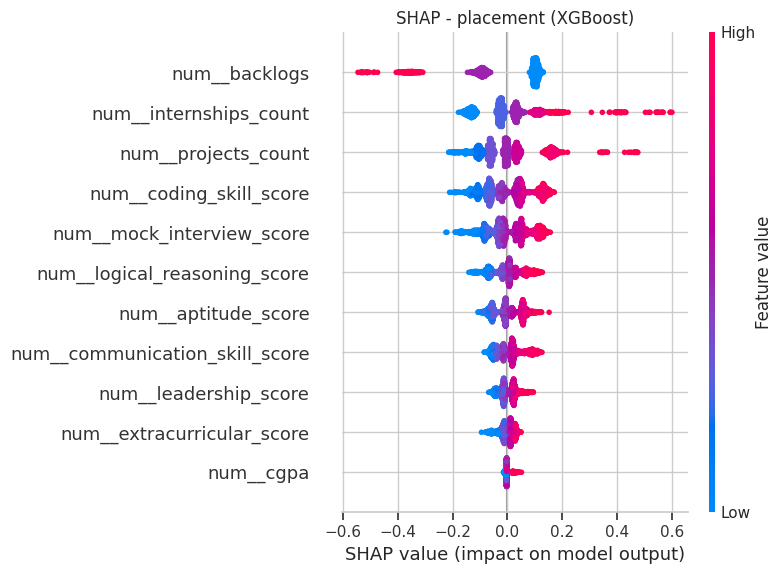

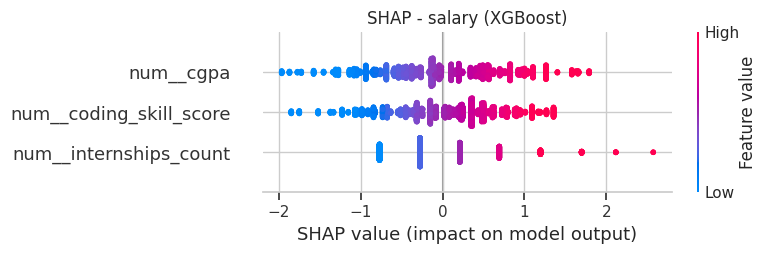

In [32]:
# [EXPLAINABILITY 2] SHAP summary for the XGBoost models (fast exact TreeExplainer) - shows direction of each feature's effect.
if shap is not None:
    try:
        for tag, m, Xs in [("placement", fitted_cls["3. XGBoost"], test_df[CLS_FEATURES]),
                           ("salary", fitted_reg["3. XGBoost"], test_placed[REG_FEATURES])]:
            Xs = Xs.sample(min(2000, len(Xs)), random_state=1)
            Xt = pd.DataFrame(m[:-1].transform(Xs), columns=m[:-1].get_feature_names_out())
            sv = shap.TreeExplainer(m.named_steps["model"]).shap_values(Xt)
            plt.figure(); shap.summary_plot(sv, Xt, show=False, max_display=12); plt.title(f"SHAP - {tag} (XGBoost)")
            savefig(f"11_shap_{tag}")
    except Exception as e:
        print("SHAP skipped:", e)
else:
    print("shap not installed - skipped (pip install shap)")

## 11. Save everything for the app (models, schema, reports)

In [33]:
# [SAVE] Persist models + a machine-readable feature schema the frontend can use to build its input form automatically.
joblib.dump(final_classifier, DIRS["models"] / "placement_classifier.joblib", compress=3)
joblib.dump(final_regressor,  DIRS["models"] / "salary_regressor.joblib",     compress=3)
joblib.dump(q10,              DIRS["models"] / "salary_q10.joblib",           compress=3)
joblib.dump(q90,              DIRS["models"] / "salary_q90.joblib",           compress=3)

INPUT_FEATURES = [c for c in CANDIDATES if c in set(CLS_FEATURES) | set(REG_FEATURES)]
LABELS = {"cgpa": "CGPA (out of 10)", "internships_count": "Internships completed", "projects_count": "Projects completed",
          "certifications_count": "Certifications", "coding_skill_score": "Coding skill (0-100)", "aptitude_score": "Aptitude score (0-100)",
          "communication_skill_score": "Communication skill (0-100)", "logical_reasoning_score": "Logical reasoning (0-100)",
          "mock_interview_score": "Mock interview score (0-100)", "backlogs": "Active backlogs", "leadership_score": "Leadership (0-100)",
          "extracurricular_score": "Extracurricular (0-100)", "hackathons_participated": "Hackathons participated", "github_repos": "GitHub repositories"}
schema_features = {}
for c in INPUT_FEATURES:
    s = train_df[c]
    if c in cat_c:
        schema_features[c] = {"type": "categorical", "label": LABELS.get(c, c.replace("_", " ").title()),
                              "options": sorted(s.unique().tolist()), "default": s.mode()[0]}
    else:
        integer = bool((s == s.round()).all())
        schema_features[c] = {"type": "integer" if integer else "float", "label": LABELS.get(c, c.replace("_", " ").title()),
                              "min": float(s.min()), "max": float(s.max()), "default": round(float(s.median()), 2)}

PROB_QUANTILES = [round(float(v), 5) for v in np.quantile(final_classifier.predict_proba(train_df[CLS_FEATURES])[:, 1], np.linspace(0, 1, 101))]
schema = {"input_features": INPUT_FEATURES, "classifier_features": CLS_FEATURES, "regressor_features": REG_FEATURES,
          "excluded_protected": PROTECTED, "features": schema_features, "currency_note": "1 LPA = Rs 1,00,000 per year",
          "probability_quantiles": PROB_QUANTILES}
(DIRS["models"] / "feature_schema.json").write_text(json.dumps(schema, indent=2))

import sklearn, xgboost, lightgbm
model_card = {
    "random_state": RANDOM_STATE, "quick_mode": QUICK_MODE, "n_rows": int(len(df)),
    "selected_classifier": FINAL_CLS_NAME, "selected_regressor": FINAL_REG_NAME,
    "engineered_features": {"classifier": USE_FE_CLS, "regressor": USE_FE_REG},
    "calibration_applied": bool(USE_CALIBRATION),
    "classifier_test_metrics": {k: float(v) for k, v in cls_metrics(y_te, p_final).items()},
    "placement_signal": signal_summary,
    "regressor_test_metrics": {k: float(v) for k, v in reg_metrics(yr_te, reg_pred[FINAL_REG_NAME]).items()},
    "salary_band_80pct_coverage": float(coverage),
    "end_to_end_expected_lpa_metrics": {k: float(v) for k, v in reg_metrics(actual, expected).items()},
    "versions": {"sklearn": sklearn.__version__, "xgboost": xgboost.__version__, "lightgbm": lightgbm.__version__,
                 "pandas": pd.__version__, "numpy": np.__version__},
}
(DIRS["models"] / "model_card.json").write_text(json.dumps(model_card, indent=2))
(DIRS["reports"] / "metrics_summary.json").write_text(json.dumps(model_card, indent=2))
print(json.dumps(model_card, indent=2))

{
  "random_state": 42,
  "quick_mode": false,
  "n_rows": 100000,
  "selected_classifier": "1. Logistic Regression",
  "selected_regressor": "1. Ridge Regression",
  "engineered_features": {
    "classifier": false,
    "regressor": false
  },
  "calibration_applied": false,
  "classifier_test_metrics": {
    "accuracy": 0.5721,
    "precision": 0.5800521333516258,
    "recall": 0.7763496143958869,
    "f1": 0.6639968590498626,
    "roc_auc": 0.5860062306147585,
    "pr_auc": 0.6199892656968442,
    "brier": 0.2422287997785116,
    "log_loss": 0.6773640372743018
  },
  "placement_signal": {
    "test_auc": 0.5860062306147585,
    "auc_ci95": [
      0.5790525910577504,
      0.593733828366678
    ],
    "placement_rate_lowest_decile": 0.4115,
    "placement_rate_highest_decile": 0.6815,
    "prob_p05": 0.4124199403733135,
    "prob_p95": 0.6650142009597597,
    "reliability_note": "Placement is only weakly predictable from these features (AUC 0.59, 95% CI 0.58-0.59). Predicted chances

In [34]:
# [SAVE] App-ready helper files: requirements, example input, README.
req = "\n".join([f"scikit-learn=={sklearn.__version__}", f"xgboost=={xgboost.__version__}", f"lightgbm=={lightgbm.__version__}",
                 f"pandas=={pd.__version__}", f"numpy=={np.__version__}", "joblib", "scipy"])
(DIRS["app"] / "requirements.txt").write_text(req + "\n")

example = {c: (schema_features[c]["default"] if schema_features[c]["type"] == "categorical" else
               (int(schema_features[c]["default"]) if schema_features[c]["type"] == "integer" else schema_features[c]["default"]))
           for c in INPUT_FEATURES}
(DIRS["app"] / "example_input.json").write_text(json.dumps(example, indent=2))

readme = f'''# ML/05_app_ready - how to use the trained models

```python
import sys; sys.path.append("ML/05_app_ready")          # so joblib can find ml_utils.FeatureEngineer
from ml_utils import PlacementPredictor
predictor = PlacementPredictor("ML/03_models")            # loads classifier, regressor and quantile models
print(predictor.predict(json.load(open("ML/05_app_ready/example_input.json"))))
```

* `feature_schema.json` (in 03_models) lists every input field with type / min / max / default -> build the frontend form from it.
* Install the exact library versions first:  `pip install -r ML/05_app_ready/requirements.txt`
* Output keys: placement_percent, profile_percentile, salary_if_placed_lpa, salary_range_lpa, salary_if_placed_inr, expected_lpa ...
* 1 LPA = Rs 1,00,000 per year.
'''
(DIRS["app"] / "README.md").write_text(readme)

root_readme = '''# Student Placement Prediction - ML part
ML/01_data -> ML/02_notebook -> ML/03_models -> ML/04_reports -> ML/05_app_ready  (run the notebook top to bottom to regenerate everything)
frontend/ -> React app (Part 2)
Next: build the backend (FastAPI/Flask) and frontend that call 05_app_ready/ml_utils.PlacementPredictor.
'''
(BASE_DIR / "README.md").write_text(root_readme)
print("Saved app-ready files.")

Saved app-ready files.


## 12. Smoke test: reload the saved models exactly as the backend will, and try "what-if" scenarios

In [35]:
# [VERIFY] Load models from disk with the same class the backend will use; compare to real test students.
predictor = PlacementPredictor(DIRS["models"])
demo = test_df.sample(5, random_state=7)
out = predictor.predict_frame(demo[INPUT_FEATURES]).round(3)
out["actual_status"] = demo["placement_status"].values
out["actual_lpa"] = demo["salary_package_lpa"].values
display(out)

print("\nSingle-student JSON (what the API will return):")
print(json.dumps(predictor.predict(demo.iloc[0][INPUT_FEATURES].to_dict()), indent=2))

,placement_probability,profile_percentile,salary_if_placed_lpa,salary_low_lpa,salary_high_lpa,expected_lpa,actual_status,actual_lpa
0,0.657,93.724,14.704,13.512,16.006,9.663,Placed,14.57
1,0.528,39.781,13.465,12.170,14.732,7.105,Not Placed,0.00
2,0.629,86.616,15.483,14.187,16.704,9.733,Placed,15.47
3,0.602,76.659,13.261,12.077,14.510,7.977,Placed,13.79
4,0.628,86.293,14.964,13.616,16.239,9.391,Placed,14.81



Single-student JSON (what the API will return):
{
  "profile_percentile": 93.7,
  "placement_probability": 0.6571,
  "placement_percent": 65.7,
  "predicted_placed": true,
  "salary_if_placed_lpa": 14.7,
  "salary_range_lpa": [
    13.51,
    16.01
  ],
  "salary_if_placed_inr": 1470395,
  "salary_range_inr": [
    1351237,
    1600606
  ],
  "salary_if_placed_text": "Rs 14,70,395 per year",
  "expected_lpa": 9.66,
  "expected_inr": 966253
}


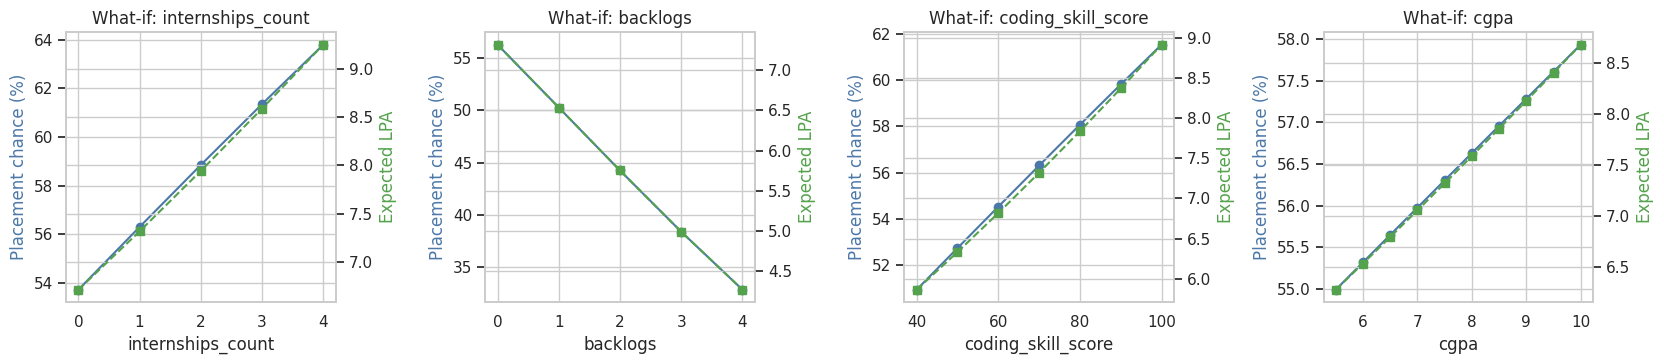

In [36]:
# [INNOVATION - what-if analysis] Vary one input at a time for an average student and watch the prediction move.
base_student = {c: schema_features[c]["default"] for c in INPUT_FEATURES}
scenarios = {"internships_count": range(0, 5), "backlogs": range(0, 5), "coding_skill_score": np.arange(40, 101, 10), "cgpa": np.arange(5.5, 10.01, 0.5)}
scenarios = {k: v for k, v in scenarios.items() if k in INPUT_FEATURES}

fig, axes = plt.subplots(1, len(scenarios), figsize=(4.2 * len(scenarios), 3.8))
axes = np.atleast_1d(axes)
for ax, (feat, values) in zip(axes, scenarios.items()):
    grid = pd.DataFrame([{**base_student, feat: v} for v in values])
    res = predictor.predict_frame(grid)
    ax.plot(list(values), 100 * res["placement_probability"], "o-", color="#4C78A8", label="Placement chance %")
    ax.set_xlabel(feat); ax.set_ylabel("Placement chance (%)", color="#4C78A8")
    ax2 = ax.twinx(); ax2.plot(list(values), res["expected_lpa"], "s--", color="#54A24B"); ax2.set_ylabel("Expected LPA", color="#54A24B")
    ax.set_title(f"What-if: {feat}")
savefig("12_what_if")

## 13. Zip the whole project folder (import straight into VS Code)

In [37]:
# [PACKAGE] Copy this notebook into 02_notebook/ if it can be found, then zip the project folder.
for cand in ["/kaggle/working/__notebook__.ipynb", "/kaggle/working/notebook.ipynb", "placement_ml_pipeline.ipynb"]:
    if Path(cand).exists():
        dest = DIRS["notebook"] / "placement_ml_pipeline.ipynb"
        if Path(cand).resolve() != dest.resolve():
            shutil.copy(cand, dest)
        break
else:
    if not (DIRS["notebook"] / "placement_ml_pipeline.ipynb").exists():
        (DIRS["notebook"] / "PUT_NOTEBOOK_HERE.txt").write_text("Download this notebook from Kaggle (File > Download) and place it in this folder.\n")

zip_path = shutil.make_archive(str(BASE_DIR), "zip", root_dir=BASE_DIR.parent, base_dir=BASE_DIR.name)
print("ZIP created:", zip_path, f"({Path(zip_path).stat().st_size/1e6:.1f} MB)\n")
for p in sorted(BASE_DIR.rglob("*")):
    if p.is_file():
        print(f"{str(p.relative_to(BASE_DIR)):<60}{p.stat().st_size/1e3:>10.0f} KB")

ZIP created: /kaggle/working/placement_project.zip (11.0 MB)

ML/01_data/student_placement_prediction_dataset_2026.csv         21452 KB
ML/02_notebook/PUT_NOTEBOOK_HERE.txt                                 0 KB
ML/03_models/feature_schema.json                                     4 KB
ML/03_models/model_card.json                                         2 KB
ML/03_models/placement_classifier.joblib                             2 KB
ML/03_models/salary_q10.joblib                                      90 KB
ML/03_models/salary_q90.joblib                                      90 KB
ML/03_models/salary_regressor.joblib                                 2 KB
ML/04_reports/ablation_feature_sets.csv                              0 KB
ML/04_reports/classification_cv_results.csv                          2 KB
ML/04_reports/classification_test_results.csv                        1 KB
ML/04_reports/feature_selection_table.csv                            3 KB
ML/04_reports/figures/01_target_distributions.png 

## 14. Summary & honest interpretation
* **Salary stage:** strongly predictable — driven mainly by **CGPA, coding skill and number of internships**.
* **Placement stage:** only **weakly** predictable from these columns (ROC-AUC well below what is usually reported for real
  campus datasets). That is a property of the data, not a bug — the no-skill reference (AUC 0.5) is shown for context and the
  calibration step makes sure the probabilities we display are honest rather than over-confident.
* Model comparison tables, curves, calibration and explanation plots are saved in `04_reports/`.
* **Next (Part 2):** backend (FastAPI/Flask) + frontend that call `05_app_ready/ml_utils.PlacementPredictor`.
* **Deployed classifier:** Logistic Regression - the four models are statistically tied, so the simplest wins (1-SE rule). Isotonic calibration is applied only if it lowers the out-of-fold Brier score.
* **What the app should show:** salary-if-placed with its 80 % range (reliable), the placement chance together with the *profile percentile* and the reliability note from `model_card.json` (honest).
